<h1>Import Dependencies</h1>

In [1]:
import tensorflow as tf 
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error
from statsmodels.tools.eval_measures import rmse
import warnings
import matplotlib.pyplot as plt
import os 
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from statsmodels.iolib.summary import summary
from keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from keras.layers import LSTM, Dense, Dropout
from keras.layers import Activation
import time



# Your code here

warnings.filterwarnings("ignore")

<h1>Importing input data file</h1>

In this case input data file is in a csv format and it is loaded in to the google coalb and convert in to the pandas datafream. Then python comand can handdle and manupulate input data file.

**CO2 Data**

Atmospheric CO2 concentrations (ppm) since 1958 to 2023 are used in this exercise and they have derived from in situ air measurements at Mauna Loa, Observatory, Hawaii: Latitude 19.5°N Longitude 155.6°W Elevation 3397m.

Data shows monthly Mauna Loa CO2 concentrations in micro-mol CO2 per mole (ppm),reported on the 2012 SIO manometric mole fraction scale. This is the standard version of the data most often sought. The monthly values have been adjusted to 24:00 hours on the 15th of each month. The missing values are denoted by -99.Last column shows the abrevated name for the data collecting staion.

<h1>Ploting the data</h1>

Plot the mean surface temperature time series. X axis-year, Y-axis monthly co2 (ppm).

Text(0, 0.5, 'co2 mole fraction (ppm)')

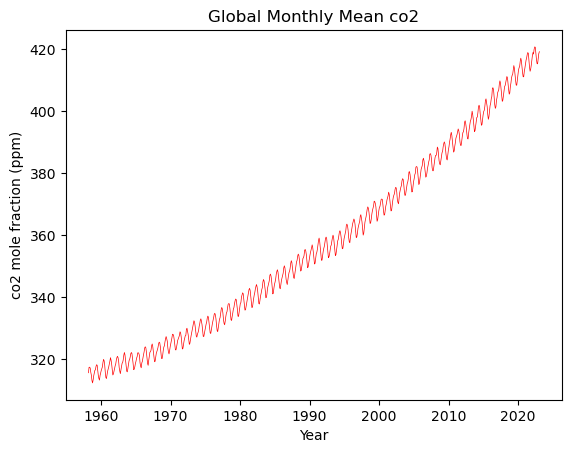

In [2]:
co2_ts = pd.read_table("co2.txt",sep='\t',index_col="year",parse_dates=True)
plt.plot(co2_ts.index, co2_ts["co2"], linewidth=0.5, color='red')
plt.title("Global Monthly Mean co2")
plt.xlabel("Year")
plt.ylabel("co2 mole fraction (ppm)")

**Figure 1.** Time Series of Global Mean CO2.The red line represents the monthly mean CO2 concentration values, centered on the middle of each month. Overall trend of CO2 concentraion is increasing from the 1959 to 2023. 

<h1>Exploring trends</h1>

We model the co2 data assuming a trend with both an annual and seasonal component. The trend component represents the underlying long-term behavior of the data

Text(0.5, 1.0, 'Global Monthly Mean CO2')

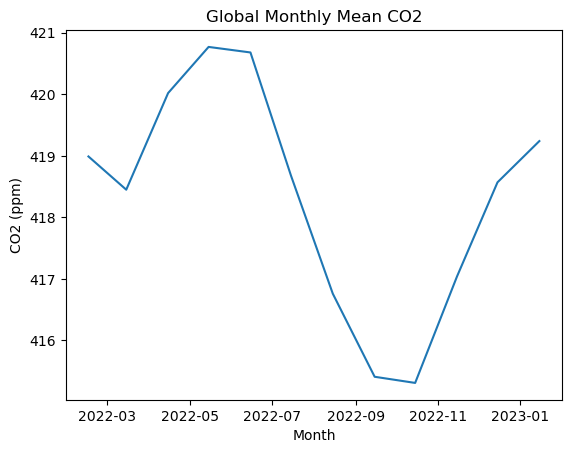

In [3]:
ts_monthly = co2_ts['co2'].tail(12)
ts_monthly = pd.DataFrame(ts_monthly, columns=['co2'])

# Plot monthly mean
plt.plot(ts_monthly.index, ts_monthly['co2'])
plt.xlabel('Month')
plt.ylabel('CO2 (ppm)')
plt.title('Global Monthly Mean CO2')


Text(0.5, 1.0, 'Global Annual Mean CO2')

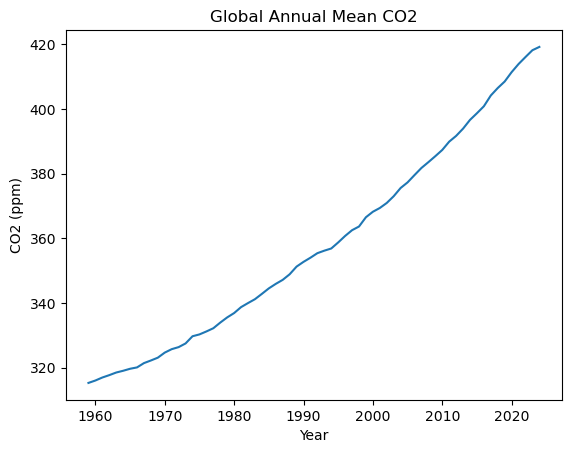

In [4]:
ts_annual = co2_ts['co2'].resample('A').mean()
ts_annual= pd.DataFrame(ts_annual, columns=['co2'])

# Plot annual mean
plt.plot(ts_annual.index, ts_annual['co2'])
plt.xlabel('Year')
plt.ylabel('CO2 (ppm)')
plt.title('Global Annual Mean CO2')

<h1> Seasonal component analysis</h1>

Seasonal component analysis, is used to identify and model the short-term, recurring patterns or cycles in a time series that occur over a fixed period of time (e.g. daily, weekly, monthly, quarterly, yearly).

In [5]:
# Let' divide into training and testing (last 16 points)
t = np.arange(len(co2_ts)) 

n_train=762 # create training data set
n_test=len(co2_ts)-n_train-1 # set up testing data set
co2_test = co2_ts[(n_train+1):] #indexing the time series co2_ts.
co2_train=co2_ts[:n_train] #Indexing train data set. 

# Create time variables, linear and quadratic trend
year = pd.Series(np.floor(t/12)) 
year2 = year**2 

# We also have seasonal components for the first three harmonics 
X = np.column_stack((np.cos(1*np.pi*t/12), np.sin(1*np.pi*t/12),
                       np.cos(2*np.pi*t/12), np.sin(2*np.pi*t/12),
                       np.cos(3*np.pi*t/12), np.sin(3*np.pi*t/12),
                      year,year2))

X_train=X[:n_train,:]
X_test=X[(n_train+1):,:]

model_trend = sm.OLS(co2_train, sm.add_constant(X_train)).fit()
print(model_trend.summary())

                            OLS Regression Results                            
Dep. Variable:                    co2   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 7.582e+04
Date:                Tue, 28 Mar 2023   Prob (F-statistic):               0.00
Time:                        11:40:57   Log-Likelihood:                -1111.4
No. Observations:                 762   AIC:                             2241.
Df Residuals:                     753   BIC:                             2283.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        315.0500      0.110   2857.412      0.0

<h1>Fitting a linear regression model</h1>

In [6]:
len(co2_train['co2'])

762

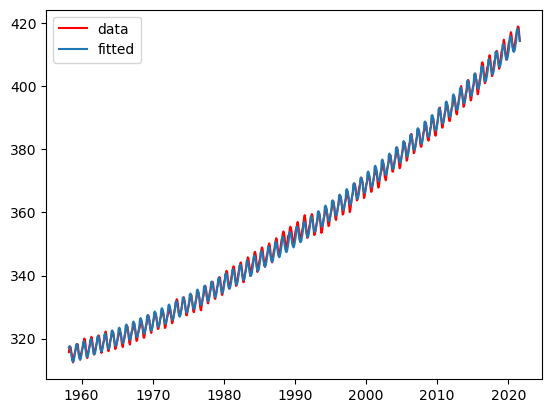

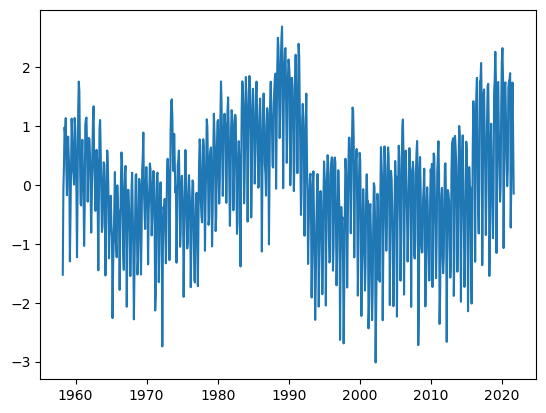

In [7]:
# Plot fitted values
model_fitted=model_trend.predict(sm.add_constant(X_train))

plt.plot(co2_train.index,co2_train['co2'],color='red',label='data')
plt.plot(co2_train.index,model_fitted, label='fitted')
plt.legend()
plt.show()

# plot residuals
residual_ts = co2_train['co2'] - model_fitted
plt.plot(co2_train.index,residual_ts)


# we also predict the trend for the test set
model_fitted_test=model_trend.predict(sm.add_constant(X_test))

<h1> ARIMA model for the residuals and forecast</h1>

From the above analysis it's pretty clear we need additional structure in the residuals. Let's find the best arima model to fit the data

<h2> Select an appropriate ARIMA model for the given time series residual</h2>

In [8]:
arima_mod=auto_arima(residual_ts)
arima_mod.summary()

pred_test=arima_mod.predict(n_periods=n_test)
arima_mod.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  762
Model:               SARIMAX(4, 1, 5)   Log Likelihood                -416.830
Date:                Tue, 28 Mar 2023   AIC                            853.659
Time:                        11:41:36   BIC                            900.006
Sample:                             0   HQIC                           871.505
                                - 762                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0034      0.008      0.407      0.684      -0.013       0.020
ar.L2         -0.9913      0.008   -131.126      0.000      -1.006      -0.976
ar.L3         -0.0077      0.007     -1.071      0.284      -0.022       0.006
ar.L4         -0.9848      0.007   -136.475      0.000      -0.999      -0.971
ma.L1         -0.5306      0.032    -16.670      0.000      -0.593      -0.468
ma.L2          0.9231      0.032     29.114      0.000       0.861       0.985
ma.L3         -0.4896      0.037    -13.208      0.000      -0.562      -0.417
ma.L4          0.8744      0.033     26.861      0.000       0.811       0.938
ma.L5         -0.5556      0.028    -19.692      0.000      -0.611      -0.500
sigma2         0.1641      0.008     20.037      0.000       0.148       0.180
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                 8.95
Prob(Q):                              0.81   Prob(JB):                         0.01
Heteroskedasticity (H):               1.90   Skew:                            -0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<h1> Plot the forecast</h1>

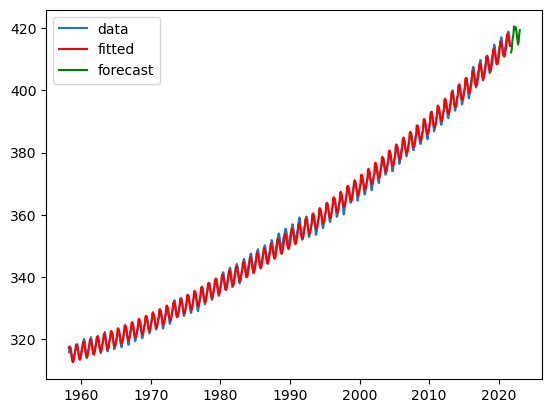

In [9]:
plt.plot(co2_train.index,co2_train['co2'],label='data')
plt.plot(co2_train.index,model_fitted, color='red',label='fitted')
plt.plot(co2_test.index,model_fitted_test+pred_test, color='green',label='forecast')
plt.legend()
plt.show()

<h1>Forecast plot with seasonal changes</h1>

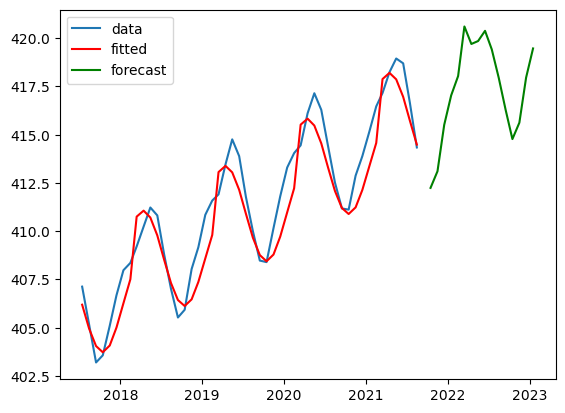

In [10]:
plt.plot(co2_train.index[-50:],co2_train['co2'].iloc[-50:],label='data')
plt.plot(co2_train.index[-50:],model_fitted[-50:], color='red',label='fitted')
plt.plot(co2_test.index[-50:],model_fitted_test[-50:]+pred_test, color='green',label='forecast')
plt.legend()
plt.show()

<h1>Error Calculation</h1>

In [11]:
arima_rmse_error = rmse(co2_train['co2'],model_fitted)  
arima_mse_error = arima_rmse_error**2
mean_value = co2_train['co2'].mean()
print(f'MSE Error: {arima_mse_error}\nRMSE Error:{arima_rmse_error}\nMean:{mean_value}')

MSE Error: 1.0823945649375768
RMSE Error:1.0403819322429513
Mean:356.2912860892388



The first line of code calculates the RMSE error between the predicted values ('model_fitted') and the actual test data (co2_train['co2']). RMSE is a measure of the difference between the predicted and actual values, where a lower value indicates better accuracy.


<h1>PART 2</h1>
<h1>Modeling with LSTM</h1>

We first scale the train_data with the function MinMaxScaler function from the sklearn.preprocessing module 


In [12]:
scaler = MinMaxScaler(feature_range=(0, 1))
co2_scaled = scaler.fit_transform(co2_ts)
#lets create our train and test data
train = co2_scaled[:n_train]
test = co2_scaled[(n_train+1):]



<h1>Creating an LSTM model using the Keras API from TensorFlow</h1>

In [13]:
n_input = 12 #number of time steps to use as input to the LSTM model
n_features = 1 #The batch_size parameter, This means that the generator will generate one sample at a time.
generator = TimeseriesGenerator(train, train,length=n_input,batch_size=1) #create a generator object 
lstm_model = Sequential() #The LSTM model is created using the Sequential class, which allows us to add layers to the model  
lstm_model.add(LSTM(40, activation='relu',input_shape = (n_input, n_features))) 
lstm_model.add(Dense(1))#The second layer is a Dense layer with one unit, which will output a single predicted value
lstm_model.compile(optimizer ='adam',loss='mse') #The model is compiled using the adam optimizer and the mean squared error 
lstm_model.summary 
print(lstm_model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 40)                6720      
                                                                 
 dense (Dense)               (None, 1)                 41        
                                                                 
Total params: 6,761
Trainable params: 6,761
Non-trainable params: 0
_________________________________________________________________
None


<h1>Train the LSTM model</h1>


In [ ]:
lstm_model.fit_generator(generator,epochs=50)

Epoch 1/50
750/750 [==============================] - 58s 75ms/step - loss: 0.0109
Epoch 2/50
750/750 [==============================] - 57s 76ms/step - loss: 8.1652e-04
Epoch 3/50
750/750 [==============================] - 55s 74ms/step - loss: 0.0010
Epoch 4/50
750/750 [==============================] - 61s 82ms/step - loss: 7.4078e-04
Epoch 5/50
750/750 [==============================] - 66s 89ms/step - loss: 7.0417e-04
Epoch 6/50
750/750 [==============================] - 60s 80ms/step - loss: 6.8383e-04
Epoch 7/50
750/750 [==============================] - 57s 76ms/step - loss: 6.5962e-04
Epoch 8/50
750/750 [==============================] - 58s 77ms/step - loss: 6.2664e-04
Epoch 9/50
750/750 [==============================] - 57s 76ms/step - loss: 5.3237e-04
Epoch 10/50
750/750 [==============================] - 58s 77ms/step - loss: 5.9029e-04
Epoch 11/50
750/750 [==============================] - 57s 76ms/step - loss: 5.3881e-04
Epoch 12/50
750/750 [============================

<h1>Training loss over the epochs of the LSTM model</h1>

In [ ]:
losses_lstm = lstm_model.history.history['loss'] #Accesses to the loss metric values from the history attribute
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.xticks(np.arange(0,21,1))
plt.plot(range(len(losses_lstm)),losses_lstm);

<h1>Predicting Global Co2 Concentraion using LSTM</h1>

In [ ]:
lstm_predictions_scaled = list() #a new list lstm_predictions_scaled is created to store the predicted values
batch = train[-n_input:] #select batch data
current_batch = batch.reshape((1,n_input,n_features))
for i in range(len(test)):
  lstm_pred = lstm_model.predict(current_batch)[0]
  lstm_predictions_scaled.append(lstm_pred)
  current_batch = np.append(current_batch[:,1:,:],[[lstm_pred]],axis =1)

In [ ]:
lstm_predictions_scaled

In [ ]:
lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)#scales back the predicted values obtained from the LSTM 
lstm_predictions

<h1>Compare the model performances (ARIMA and LSTM)</h1>

In [ ]:
co2_test['lstm_predictions'] = lstm_predictions[:16] # test data for lstm prediction
co2_test['ARIMA_Predictions'] = model_fitted_test[-50:]+pred_test # test dat for ARIMA prediction
co2_test

<h1>Ploting Real CO2 data and LSTM predicted CO2 data</h1>

In [ ]:
plt.plot(co2_train.index[-50:],co2_train['co2'].iloc[-50:], color='red',label='Data')
plt.plot(co2_train.index[-50:],model_fitted[-50:], label='ARIMA fitted')
plt.plot(co2_test.index[-50:],model_fitted_test[-50:]+pred_test, color='green',label='ARIMA forecast')
plt.plot(co2_train.index[-50:],lstm_predictions, color='blue',label='LSTM')
plt.legend()
plt.show()





